# Recherche du nombre optimal de clusters (K)

Ce notebook évalue plusieurs valeurs de K avec l'inertie et le score de silhouette pour guider le choix du nombre de segments final.

## Import des librairies et configuration des chemins

In [1]:
from pathlib import Path  # Construire des chemins robustes.
import os  # Créer les dossiers de sortie si besoin.
import pandas as pd  # Manipuler les tables.
import matplotlib.pyplot as plt  # Construire les graphiques elbow / silhouette.
from sklearn.cluster import KMeans  # Entraîner K-Means pour chaque K.
from sklearn.metrics import silhouette_score  # Calculer le score de silhouette.

PROJECT_ROOT = Path('.')  # Racine du projet.
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'  # Dossier des données préparées.
PLOTS_DIR = PROJECT_ROOT / 'plots'  # Dossier des graphiques.
os.makedirs(PLOTS_DIR, exist_ok=True)  # S'assurer que le dossier plots existe.

## Charger la matrice standardisée

In [2]:
X_scaled_df = pd.read_csv(PROCESSED_DIR / 'X_scaled.csv')  # Charger les features RFM standardisées.

## Évaluer K de 2 à 10

In [3]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled_df, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k}: Inertie={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

K=2: Inertie=10036.81, Silhouette=0.3110


K=3: Inertie=7254.20, Silhouette=0.3410


K=4: Inertie=5318.05, Silhouette=0.3343


K=5: Inertie=4661.99, Silhouette=0.3382


K=6: Inertie=4041.21, Silhouette=0.3145


K=7: Inertie=3522.40, Silhouette=0.2946


K=8: Inertie=3163.65, Silhouette=0.2966


K=9: Inertie=2902.72, Silhouette=0.3012


K=10: Inertie=2708.55, Silhouette=0.2773


## Tracer les courbes elbow et silhouette

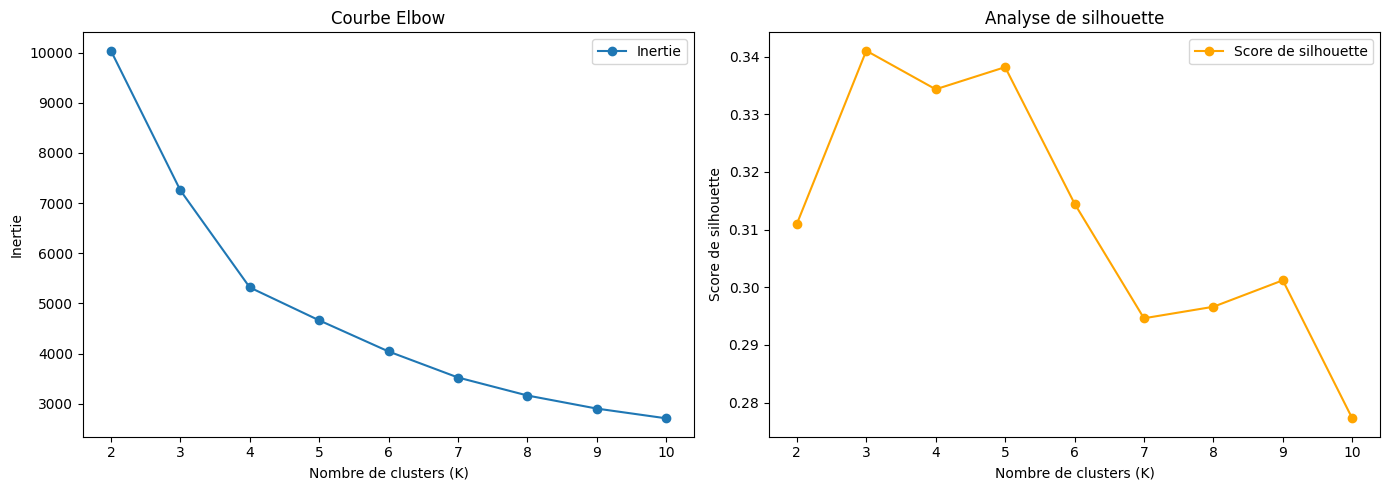

Graphique sauvegardé : plots/elbow_silhouette_analysis.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Créer la grille 1x2.
axes[0].plot(list(K_range), inertias, marker='o', label='Inertie')  # Courbe elbow.
axes[0].set_title('Courbe Elbow')  # Titre.
axes[0].set_xlabel('Nombre de clusters (K)')  # Label axe X.
axes[0].set_ylabel('Inertie')  # Label axe Y.
axes[0].legend()  # Légende.
axes[1].plot(list(K_range), silhouette_scores, marker='o', color='orange', label='Score de silhouette')  # Courbe silhouette.
axes[1].set_title('Analyse de silhouette')  # Titre.
axes[1].set_xlabel('Nombre de clusters (K)')  # Label axe X.
axes[1].set_ylabel('Score de silhouette')  # Label axe Y.
axes[1].legend()  # Légende.
plt.tight_layout()  # Ajuster la mise en page.
plot_path = PLOTS_DIR / 'elbow_silhouette_analysis.png'  # Chemin du graphique.
plt.savefig(plot_path, dpi=300)  # Sauvegarder le graphique.
plt.show()  # Afficher le graphique.
print(f'Graphique sauvegardé : {plot_path}')  # Confirmer le chemin.

## Sélectionner K et sauvegarder l'analyse

**Note métier** : le score de silhouette maximal peut suggérer un K statistique (ex. K=3), mais le nombre final de segments utilisé dans le notebook suivant est fixé à **K=4** pour correspondre aux 4 catégories business demandées : Champions, Réguliers, À Surveiller, Perdus. Cette cellule reporte le K optimal statistique à titre indicatif.

In [5]:
optimal_k_stat = list(K_range)[int(pd.Series(silhouette_scores).idxmax())]  # K avec le meilleur score de silhouette (indicatif).
print(f'K optimal (statistique, silhouette) = {optimal_k_stat}')  # Afficher le K statistique.
print('K retenu pour la segmentation business = 4 (Champions / Réguliers / À Surveiller / Perdus)')  # Rappeler le choix business.
analysis_df = pd.DataFrame({'K': list(K_range), 'Inertia': inertias, 'Silhouette_Score': silhouette_scores})  # Construire la table d'analyse.
analysis_file = PROCESSED_DIR / 'optimal_k_analysis.csv'  # Chemin de sortie.
analysis_df.to_csv(analysis_file, index=False)  # Sauvegarder l'analyse.
print(f'Sauvegardé : {analysis_file}')  # Confirmer le chemin.

K optimal (statistique, silhouette) = 3
K retenu pour la segmentation business = 4 (Champions / Réguliers / À Surveiller / Perdus)
Sauvegardé : data/processed/optimal_k_analysis.csv
